In [1]:
#importing all the important libraries

import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, make_scorer
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, VotingClassifier

import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


**This step loads the TCGA glioma dataset into a pandas DataFrame for analysis. The dataset contains clinical and genomic features used to predict glioma grade (LGG vs GBM).**
**The first five rows of the dataset can be previewed with the help of the head() function. This assists in confirming the data is loaded properly and gives the first idea of the format, feature names and data type and sample values.this step gives a general idea of the structure of the data**

In [2]:
# Load dataset
df = pd.read_csv("tcga_glioma_2026.csv")

# Preview dataset
df.head()

,Grade,Project,Case_ID,Gender,Age_at_diagnosis,Primary_Diagnosis,Race,IDH1,TP53,ATRX,...,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA
0,LGG,TCGA-LGG,TCGA-DU-8164,Male,51 years 108 days,"Oligodendroglioma, NOS",white,MUTATED,NOT_MUTATED,NOT_MUTATED,...,MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED
1,LGG,TCGA-LGG,TCGA-QH-A6CY,Male,38 years 261 days,Mixed glioma,white,MUTATED,NOT_MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED
2,LGG,TCGA-LGG,TCGA-HW-A5KM,Male,35 years 62 days,"Astrocytoma, NOS",white,MUTATED,MUTATED,MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED
3,LGG,TCGA-LGG,TCGA-E1-A7YE,Female,32 years 283 days,"Astrocytoma, anaplastic",white,MUTATED,MUTATED,MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,MUTATED,NOT_MUTATED
4,LGG,TCGA-LGG,TCGA-S9-A6WG,Male,31 years 187 days,"Astrocytoma, anaplastic",white,MUTATED,MUTATED,MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED


**df.shape gives us the count of rows and columns and this enables us to comprehend the dataset size.df.columns represents all feature names, which provides an idea of what kind of variables could be used to conduct the analysis, including clinical characteristics and signs of the gene mutation.**

In [3]:
print(df.shape)
print(df.columns)

(861, 27)
Index(['Grade', 'Project', 'Case_ID', 'Gender', 'Age_at_diagnosis',
       'Primary_Diagnosis', 'Race', 'IDH1', 'TP53', 'ATRX', 'PTEN', 'EGFR',
       'CIC', 'MUC16', 'PIK3CA', 'NF1', 'PIK3R1', 'FUBP1', 'RB1', 'NOTCH1',
       'BCOR', 'CSMD3', 'SMARCA4', 'GRIN2A', 'IDH2', 'FAT4', 'PDGFRA'],
      dtype='object')


**This initial check is needed to know the dimensionality of a dataset, and to inform further preprocessing and feature selections steps.
Here missing value markers in the data that do not match the non-standard statistics are called back and put in place of NaN to guarantee that non-standard missing data is treated in the same way.Real-world clinical datasets often contain placeholders such as “Not Reported” or “--” instead of true null values. When it comes to preprocessing these need to be standardised beforehand since machine learning models and imputation methods depend on the appropriate NaN representation.
Missing values are measured after replacement of each column. Only those columns that contain missing data are presented in the descending order, to point out characteristics that might need imputation, or additional consideration.**

In [4]:
# These are non-standard missing-value markers seen in the dataset
missing_markers = ["Not Reported", "not reported", "--"]
df = df.replace(missing_markers, np.nan)

print("\nMissing values per column after replacing hidden markers:")
display(df.isna().sum()[df.isna().sum() > 0].sort_values(ascending=False))



Missing values per column after replacing hidden markers:


Race                 22
Age_at_diagnosis      5
Gender                4
Primary_Diagnosis     4
dtype: int64

**The Age_at_diagnosis feature is stored as a string (e.g., “51 years 108 days”) and must be converted into a numeric format for modelling.
A custom function extracts years and days, converts them into a single continuous value (years), and handles missing or invalid entries by returning NaN.**

In [5]:
## Function to convert age string into numeric years
def convert_age_to_years(age_value):
    """
    Convert age strings such as '51 years 108 days' into a floating-point number of years.
    If the value is missing or malformed, return NaN.
    """
    if pd.isna(age_value): # Check if value is already missing
        return np.nan

    try: # Split string into components
        parts = str(age_value).split()
        years = int(parts[0]) # Extract years and days
        days = int(parts[2])
        return years + (days / 365.0)# Convert to continuous years
    except Exception: 
      return np.nan # Handle any unexpected format errors

df["Age_at_diagnosis"] = df["Age_at_diagnosis"].apply(convert_age_to_years)# Apply conversion function to Age_at_diagnosis column

# Preview converted values
print("\nConverted age preview:")
display(df["Age_at_diagnosis"].head())


Converted age preview:


0    51.295890
1    38.715068
2    35.169863
3    32.775342
4    31.512329
Name: Age_at_diagnosis, dtype: float64

**Irrelevant and leakage columns are eliminated to maintain the model to learn influential patterns.
identifiers like Case_ID and Project are not predictive; meanwhile, Primary Diagnosis correlates with the target variable quite tightly and may cause data leakage. Elimination of these characteristics enhances generalisation of the models.**

In [6]:
# 5. REMOVE IRRELEVANT / LEAKAGE-PRONE COLUMNS
# Case_ID and Project are identifiers, not biological predictors.
# Primary_Diagnosis is closely related to grade and may introduce leakage.
columns_to_drop = ["Case_ID", "Project", "Primary_Diagnosis"]
df = df.drop(columns=columns_to_drop, errors="ignore")

print("\nRemaining columns:")
print(df.columns.tolist())



Remaining columns:
['Grade', 'Gender', 'Age_at_diagnosis', 'Race', 'IDH1', 'TP53', 'ATRX', 'PTEN', 'EGFR', 'CIC', 'MUC16', 'PIK3CA', 'NF1', 'PIK3R1', 'FUBP1', 'RB1', 'NOTCH1', 'BCOR', 'CSMD3', 'SMARCA4', 'GRIN2A', 'IDH2', 'FAT4', 'PDGFRA']



**The data is divided into features (X) and target (y) such that Grade is the prediction variable (LGG vs GBM).
LabelEncoder encodes the target labels as numbers because the machine learning model is fed on numbers. This also validates labels of classes and dimensions of datasets.**


In [7]:
# 6. DEFINE FEATURES AND TARGET
X = df.drop(columns=["Grade"])
y = df["Grade"]

# Encode target labels: e.g. GBM / LGG -> 0 / 1
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("\nTarget classes:", label_encoder.classes_)
print("Feature matrix shape:", X.shape)




Target classes: ['GBM' 'LGG']
Feature matrix shape: (861, 23)


**Features are classified into numerical and categorical to facilitate proper preprocessing.Ageing at diagnosis has been considered as a numerical variable whereas the other variables (e.g., my mutation of the gene, demographic variables) are all categorical. This division is necessary to use scaling in cases of numeric data and encoding in cases of categorical data in the pipeline.**

In [8]:
# 7. IDENTIFY COLUMN TYPES
numeric_features = ["Age_at_diagnosis"]
categorical_features = [col for col in X.columns if col not in numeric_features]

print("\nNumeric features:", numeric_features)
print("Categorical features:", categorical_features)



Numeric features: ['Age_at_diagnosis']
Categorical features: ['Gender', 'Race', 'IDH1', 'TP53', 'ATRX', 'PTEN', 'EGFR', 'CIC', 'MUC16', 'PIK3CA', 'NF1', 'PIK3R1', 'FUBP1', 'RB1', 'NOTCH1', 'BCOR', 'CSMD3', 'SMARCA4', 'GRIN2A', 'IDH2', 'FAT4', 'PDGFRA']


In [9]:
# 8. PREPROCESSING PIPELINE

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

transformers = []

if len(numeric_features) > 0:
    transformers.append(("num", numeric_transformer, numeric_features))

if len(categorical_features) > 0:
    transformers.append(("cat", categorical_transformer, categorical_features))

preprocessor = ColumnTransformer(transformers=transformers)

In [10]:
# 9. DEFINE SPECIFICITY SCORER

def specificity_score(y_true, y_pred):
    """
    Calculate specificity = TN / (TN + FP)
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp)

specificity_scorer = make_scorer(specificity_score)

In [11]:
# 10. DEFINE MODELS
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42)
}

In [12]:
# Define features and target
X = df.drop(columns=["Grade"])
y = df["Grade"]

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Identify column types safely
numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

# Preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

transformers = []

if numeric_features:
    transformers.append(("num", numeric_transformer, numeric_features))

if categorical_features:
    transformers.append(("cat", categorical_transformer, categorical_features))

preprocessor = ColumnTransformer(transformers=transformers)

Numeric features: ['Age_at_diagnosis']
Categorical features: ['Gender', 'Race', 'IDH1', 'TP53', 'ATRX', 'PTEN', 'EGFR', 'CIC', 'MUC16', 'PIK3CA', 'NF1', 'PIK3R1', 'FUBP1', 'RB1', 'NOTCH1', 'BCOR', 'CSMD3', 'SMARCA4', 'GRIN2A', 'IDH2', 'FAT4', 'PDGFRA']


In [13]:
from sklearn.model_selection import StratifiedKFold

# DEFINE CV HERE (same cell)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "specificity": specificity_scorer
}

selector_model = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    max_iter=2000,
    random_state=42
)

selected_models = {
    "LR + Feature Selection": LogisticRegression(max_iter=2000, random_state=42),
    "SVM + Feature Selection": SVC(probability=True, random_state=42),
    "RF + Feature Selection": RandomForestClassifier(n_estimators=200, random_state=42),
    "GB + Feature Selection": GradientBoostingClassifier(random_state=42)
}

fs_results = []

for model_name, model in selected_models.items():

    fs_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("selector", SelectFromModel(selector_model)),
        ("classifier", model)
    ])

    scores = cross_validate(
        fs_pipeline,
        X,
        y_encoded,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    fs_results.append({
        "Model": model_name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1-score": scores["test_f1"].mean(),
        "Specificity": scores["test_specificity"].mean(),
        "AUC": scores["test_roc_auc"].mean()
    })

fs_results_df = pd.DataFrame(fs_results).sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

print("\nFeature-selection-based model comparison:")
display(fs_results_df)


Feature-selection-based model comparison:


,Model,Accuracy,Precision,Recall,F1-score,Specificity,AUC
0,LR + Feature Selection,0.874593,0.927981,0.849778,0.886813,0.908828,0.923695
1,SVM + Feature Selection,0.874587,0.939578,0.837758,0.885503,0.925419,0.919730
2,GB + Feature Selection,0.858321,0.913040,0.835758,0.872225,0.889422,0.925133
3,RF + Feature Selection,0.850181,0.888477,0.849778,0.868090,0.850875,0.916493


In [14]:
from itertools import combinations

base_models = {
    "lr": LogisticRegression(max_iter=2000, random_state=42),
    "svm": SVC(probability=True, random_state=42),
    "rf": RandomForestClassifier(n_estimators=200, random_state=42),
    "ada": AdaBoostClassifier(random_state=42),
    "gb": GradientBoostingClassifier(random_state=42)
}

ensemble_results = []

for k in [3, 4]:
    for combo in combinations(base_models.items(), k):

        names = [name for name, _ in combo]
        estimators = [(name, model) for name, model in combo]

        pipeline = Pipeline(steps=[
            ("preprocessor", preprocessor),
            ("classifier", VotingClassifier(
                estimators=estimators,
                voting="soft"
            ))
        ])

        scores = cross_validate(
            pipeline,
            X,
            y_encoded,
            cv=cv,
            scoring=scoring,
            n_jobs=-1,
            error_score="raise"
        )

        ensemble_results.append({
            "Model": " + ".join(names),
            "Accuracy": scores["test_accuracy"].mean(),
            "Precision": scores["test_precision"].mean(),
            "Recall": scores["test_recall"].mean(),
            "F1-score": scores["test_f1"].mean(),
            "Specificity": scores["test_specificity"].mean(),
            "AUC": scores["test_roc_auc"].mean()
        })

ensemble_df = pd.DataFrame(ensemble_results).sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

print("\nEnsemble search results:")
display(ensemble_df.head(10))


Ensemble search results:


,Model,Accuracy,Precision,Recall,F1-score,Specificity,AUC
0,lr + svm + gb,0.875749,0.935944,0.843778,0.887097,0.919901,0.927434
1,lr + svm + ada,0.875749,0.937868,0.841758,0.886852,0.922679,0.926568
2,lr + ada + gb,0.875749,0.933814,0.845778,0.887374,0.917085,0.926857
3,lr + svm + rf + ada,0.875749,0.937817,0.841758,0.886892,0.922679,0.928083
4,svm + rf + ada,0.875743,0.934133,0.845758,0.887374,0.917161,0.924895
5,lr + rf + ada + gb,0.874593,0.931953,0.845758,0.886489,0.914384,0.928852
6,lr + svm + rf,0.874593,0.935701,0.841758,0.885971,0.919939,0.926175
7,lr + svm + ada + gb,0.874587,0.935773,0.841778,0.885918,0.919901,0.927657
8,lr + rf + ada,0.873431,0.929668,0.845758,0.885529,0.911644,0.929027
9,lr + svm + rf + gb,0.873431,0.933690,0.841758,0.885042,0.917161,0.928631


In [15]:
# Recreate results_df
results = []

for model_name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

    scores = cross_validate(
        pipeline,
        X,
        y_encoded,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    results.append({
        "Model": model_name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1-score": scores["test_f1"].mean(),
        "Specificity": scores["test_specificity"].mean(),
        "AUC": scores["test_roc_auc"].mean()
    })

results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

print("results_df recreated")
display(results_df)

results_df recreated


,Model,Accuracy,Precision,Recall,F1-score,Specificity,AUC
0,SVM,0.874587,0.939578,0.837758,0.885503,0.925419,0.912505
1,Logistic Regression,0.873431,0.927827,0.847778,0.885693,0.908828,0.923532
2,AdaBoost,0.867610,0.932750,0.831758,0.879118,0.917047,0.919047
3,Gradient Boosting,0.858334,0.907835,0.841778,0.873048,0.881164,0.924872
4,Random Forest,0.851344,0.889961,0.849778,0.868905,0.853691,0.914943


In [16]:
final_results = pd.concat([
    results_df,
    fs_results_df,
    ensemble_df.head(5)   # top ensembles only
], ignore_index=True)

final_results = final_results.sort_values(by="Accuracy", ascending=False)

display(final_results)
print("results_df exists:", 'results_df' in globals())
print("fs_results_df exists:", 'fs_results_df' in globals())
print("ensemble_df exists:", 'ensemble_df' in globals())

,Model,Accuracy,Precision,Recall,F1-score,Specificity,AUC
9,lr + svm + gb,0.875749,0.935944,0.843778,0.887097,0.919901,0.927434
12,lr + svm + rf + ada,0.875749,0.937817,0.841758,0.886892,0.922679,0.928083
10,lr + svm + ada,0.875749,0.937868,0.841758,0.886852,0.922679,0.926568
11,lr + ada + gb,0.875749,0.933814,0.845778,0.887374,0.917085,0.926857
13,svm + rf + ada,0.875743,0.934133,0.845758,0.887374,0.917161,0.924895
5,LR + Feature Selection,0.874593,0.927981,0.849778,0.886813,0.908828,0.923695
0,SVM,0.874587,0.939578,0.837758,0.885503,0.925419,0.912505
6,SVM + Feature Selection,0.874587,0.939578,0.837758,0.885503,0.925419,0.919730
1,Logistic Regression,0.873431,0.927827,0.847778,0.885693,0.908828,0.923532
2,AdaBoost,0.867610,0.932750,0.831758,0.879118,0.917047,0.919047


results_df exists: True
fs_results_df exists: True
ensemble_df exists: True


In [17]:
ensemble_df.head(5)

,Model,Accuracy,Precision,Recall,F1-score,Specificity,AUC
0,lr + svm + gb,0.875749,0.935944,0.843778,0.887097,0.919901,0.927434
1,lr + svm + ada,0.875749,0.937868,0.841758,0.886852,0.922679,0.926568
2,lr + ada + gb,0.875749,0.933814,0.845778,0.887374,0.917085,0.926857
3,lr + svm + rf + ada,0.875749,0.937817,0.841758,0.886892,0.922679,0.928083
4,svm + rf + ada,0.875743,0.934133,0.845758,0.887374,0.917161,0.924895


In [18]:
# Define voting pipeline
voting_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("selector", SelectFromModel(selector_model)),
    ("classifier", VotingClassifier(
        estimators=[
            ("lr", LogisticRegression(max_iter=2000, random_state=42)),
            ("svm", SVC(probability=True, random_state=42)),
            ("rf", RandomForestClassifier(n_estimators=200, random_state=42))
        ],
        voting="soft"
    ))
])

# Run cross-validation
voting_scores = cross_validate(
    voting_pipeline,
    X,
    y_encoded,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [19]:

# --- create results table ---
voting_results = pd.DataFrame([{
    "Model": "Soft Voting Ensemble (LR + SVM + RF)",
    "Accuracy": voting_scores["test_accuracy"].mean(),
    "Precision": voting_scores["test_precision"].mean(),
    "Recall": voting_scores["test_recall"].mean(),
    "F1-score": voting_scores["test_f1"].mean(),
    "Specificity": voting_scores["test_specificity"].mean(),
    "AUC": voting_scores["test_roc_auc"].mean()
}])
# Round for clean display
voting_results = voting_results.round(3)

display(voting_results)

,Model,Accuracy,Precision,Recall,F1-score,Specificity,AUC
0,Soft Voting Ensemble (LR + SVM + RF),0.876,0.936,0.844,0.887,0.92,0.927


In [20]:
print("\nVoting ensemble results:")
display(voting_results)

# Get cross-validated probabilities
y_prob = cross_val_predict(
    voting_pipeline,
    X,
    y_encoded,
    cv=cv,
    method="predict_proba"
)[:, 1]

# Test different thresholds
thresholds = np.arange(0.1, 0.9, 0.05)
threshold_results = []

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_encoded, y_pred).ravel()

    threshold_results.append({
        "Threshold": t,
        "Precision": precision_score(y_encoded, y_pred),
        "Recall": recall_score(y_encoded, y_pred),
        "F1-score": f1_score(y_encoded, y_pred),
        "Specificity": tn / (tn + fp)
    })

threshold_df = pd.DataFrame(threshold_results)
print("\nThreshold tuning results:")
display(threshold_df)


Voting ensemble results:


,Model,Accuracy,Precision,Recall,F1-score,Specificity,AUC
0,Soft Voting Ensemble (LR + SVM + RF),0.876,0.936,0.844,0.887,0.92,0.927



Threshold tuning results:


C:\Program Files\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,Threshold,Precision,Recall,F1-score,Specificity
0,0.10,0.627054,0.993988,0.768992,0.185083
1,0.15,0.690240,0.977956,0.809287,0.395028
2,0.20,0.751196,0.943888,0.836590,0.569061
3,0.25,0.806738,0.911824,0.856068,0.698895
4,0.30,0.846449,0.883768,0.864706,0.779006
5,0.35,0.875752,0.875752,0.875752,0.828729
6,0.40,0.912951,0.861723,0.886598,0.886740
7,0.45,0.930131,0.853707,0.890282,0.911602
8,0.50,0.935556,0.843687,0.887250,0.919890
9,0.55,0.939597,0.841683,0.887949,0.925414


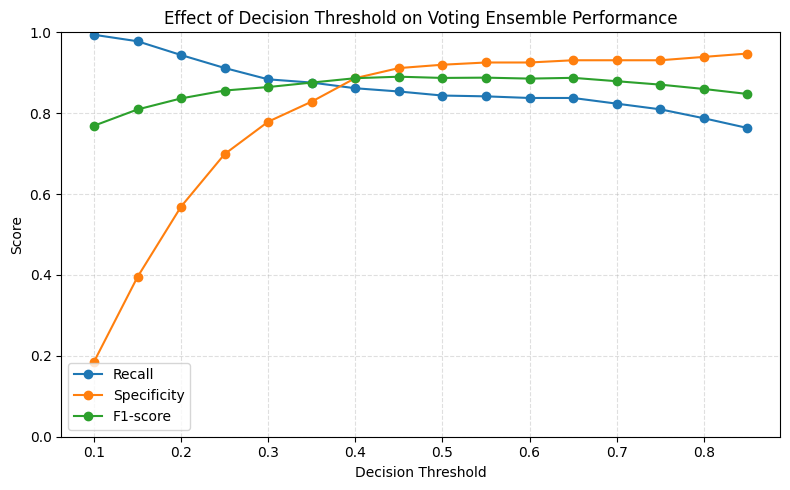

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(threshold_df["Threshold"], threshold_df["Recall"], marker="o", label="Recall")
plt.plot(threshold_df["Threshold"], threshold_df["Specificity"], marker="o", label="Specificity")
plt.plot(threshold_df["Threshold"], threshold_df["F1-score"], marker="o", label="F1-score")

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Effect of Decision Threshold on Voting Ensemble Performance")
plt.ylim(0.0, 1.0)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
# 15. FINAL COMPARISON TABLE
final_results = pd.concat([results_df, fs_results_df, voting_results], ignore_index=True)
final_results = final_results.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

print("\nFinal comparison of all models:")
display(final_results)


Final comparison of all models:


,Model,Accuracy,Precision,Recall,F1-score,Specificity,AUC
0,Soft Voting Ensemble (LR + SVM + RF),0.876000,0.936000,0.844000,0.887000,0.920000,0.927000
1,LR + Feature Selection,0.874593,0.927981,0.849778,0.886813,0.908828,0.923695
2,SVM + Feature Selection,0.874587,0.939578,0.837758,0.885503,0.925419,0.919730
3,SVM,0.874587,0.939578,0.837758,0.885503,0.925419,0.912505
4,Logistic Regression,0.873431,0.927827,0.847778,0.885693,0.908828,0.923532
5,AdaBoost,0.867610,0.932750,0.831758,0.879118,0.917047,0.919047
6,Gradient Boosting,0.858334,0.907835,0.841778,0.873048,0.881164,0.924872
7,GB + Feature Selection,0.858321,0.913040,0.835758,0.872225,0.889422,0.925133
8,Random Forest,0.851344,0.889961,0.849778,0.868905,0.853691,0.914943
9,RF + Feature Selection,0.850181,0.888477,0.849778,0.868090,0.850875,0.916493


In [23]:
# 16. TRAIN FINAL MODEL ON FULL DATA FOR INTERPRETATION
# Fit one final interpretable model pipeline to inspect selected features.
final_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("selector", SelectFromModel(selector_model)),
    ("classifier", LogisticRegression(max_iter=2000, random_state=42))
])

final_pipeline.fit(X, y_encoded)

# Extract transformed feature names after preprocessing
ohe = final_pipeline.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
encoded_cat_names = ohe.get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(encoded_cat_names)

# Get selected feature mask
selector = final_pipeline.named_steps["selector"]
selected_mask = selector.get_support()
selected_feature_names = np.array(all_feature_names)[selected_mask]

print("\nSelected features from embedded feature selection:")
for feature in selected_feature_names:
    print("-", feature)



Selected features from embedded feature selection:
- Age_at_diagnosis
- Gender_Male
- Race_white
- IDH1_NOT_MUTATED
- TP53_NOT_MUTATED
- PTEN_NOT_MUTATED
- EGFR_NOT_MUTATED
- CIC_NOT_MUTATED
- MUC16_NOT_MUTATED
- PIK3CA_NOT_MUTATED
- NF1_NOT_MUTATED
- PIK3R1_NOT_MUTATED
- RB1_NOT_MUTATED
- NOTCH1_NOT_MUTATED
- CSMD3_NOT_MUTATED
- SMARCA4_NOT_MUTATED
- GRIN2A_NOT_MUTATED
- IDH2_NOT_MUTATED
- PDGFRA_NOT_MUTATED


Number of transformed features: 25
Number of importance values: 25


,Feature,Importance
5,IDH1_NOT_MUTATED,0.694
0,Age_at_diagnosis,0.129
22,IDH2_NOT_MUTATED,0.062
9,EGFR_NOT_MUTATED,0.016
6,TP53_NOT_MUTATED,0.013
21,GRIN2A_NOT_MUTATED,0.012
8,PTEN_NOT_MUTATED,0.011
13,NF1_NOT_MUTATED,0.010
4,Race_white,0.010
17,NOTCH1_NOT_MUTATED,0.010


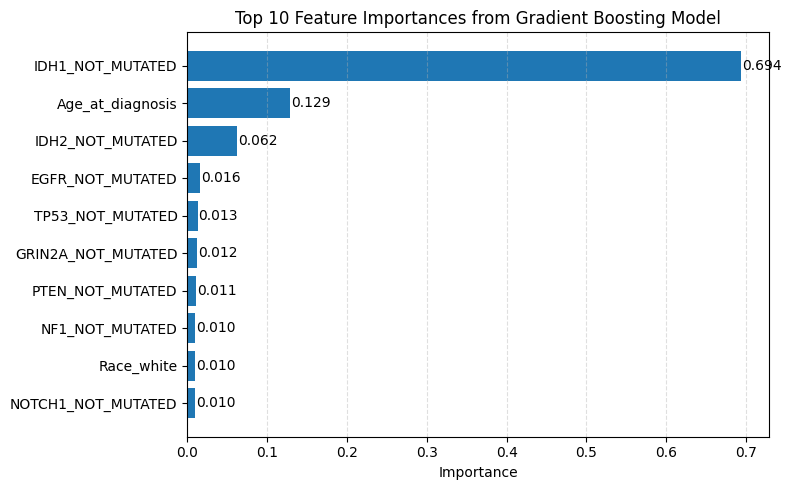

In [24]:
# Train Gradient Boosting model on full data for supplementary feature-importance analysis
gb_model = GradientBoostingClassifier(random_state=42)
gb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", gb_model)
])

gb_pipeline.fit(X, y_encoded)

# Extract feature importances
importances = gb_model.feature_importances_

# Get feature names after one-hot encoding
ohe = gb_pipeline.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
encoded_names = ohe.get_feature_names_out(categorical_features)
all_names = numeric_features + list(encoded_names)

print("Number of transformed features:", len(all_names))
print("Number of importance values:", len(importances))

# Build top-10 importance table
importance_df = pd.DataFrame({
    "Feature": all_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False).head(10).round(3)

display(importance_df)

# Plot top features
plt.figure(figsize=(8, 5))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances from Gradient Boosting Model")
plt.xlabel("Importance")
plt.grid(axis="x", linestyle="--", alpha=0.4)

for i, v in enumerate(importance_df["Importance"]):
    plt.text(v + 0.001, i, f"{v:.3f}", va="center")

plt.tight_layout()
plt.show()

In [25]:
# 0. CLEAN RESULTS TABLES
results_df = results_df.copy()
fs_results_df = fs_results_df.copy()
voting_results = voting_results.copy()

metric_cols = ["Accuracy", "Precision", "Recall", "F1-score", "Specificity", "AUC"]

for df_ in [results_df, fs_results_df, voting_results]:
    for col in metric_cols:
        if col in df_.columns:
            df_[col] = df_[col].round(3)

cols = ["Model", "Accuracy", "Precision", "Recall", "F1-score", "Specificity", "AUC"]
results_df = results_df[cols]
fs_results_df = fs_results_df[cols]
voting_results = voting_results[cols]

print("Baseline results:")
display(results_df)

print("Feature-selection results:")
display(fs_results_df)

print("Voting results:")
display(voting_results)

Baseline results:


,Model,Accuracy,Precision,Recall,F1-score,Specificity,AUC
0,SVM,0.875,0.940,0.838,0.886,0.925,0.913
1,Logistic Regression,0.873,0.928,0.848,0.886,0.909,0.924
2,AdaBoost,0.868,0.933,0.832,0.879,0.917,0.919
3,Gradient Boosting,0.858,0.908,0.842,0.873,0.881,0.925
4,Random Forest,0.851,0.890,0.850,0.869,0.854,0.915


Feature-selection results:


,Model,Accuracy,Precision,Recall,F1-score,Specificity,AUC
0,LR + Feature Selection,0.875,0.928,0.850,0.887,0.909,0.924
1,SVM + Feature Selection,0.875,0.940,0.838,0.886,0.925,0.920
2,GB + Feature Selection,0.858,0.913,0.836,0.872,0.889,0.925
3,RF + Feature Selection,0.850,0.888,0.850,0.868,0.851,0.916


Voting results:


,Model,Accuracy,Precision,Recall,F1-score,Specificity,AUC
0,Soft Voting Ensemble (LR + SVM + RF),0.876,0.936,0.844,0.887,0.92,0.927


In [26]:
# 12. EVALUATE BASE MODELS

results = []

for model_name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

    scores = cross_validate(
        pipeline,
        X,
        y_encoded,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    results.append({
        "Model": model_name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1-score": scores["test_f1"].mean(),
        "Specificity": scores["test_specificity"].mean(),
        "AUC": scores["test_roc_auc"].mean()
    })

results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

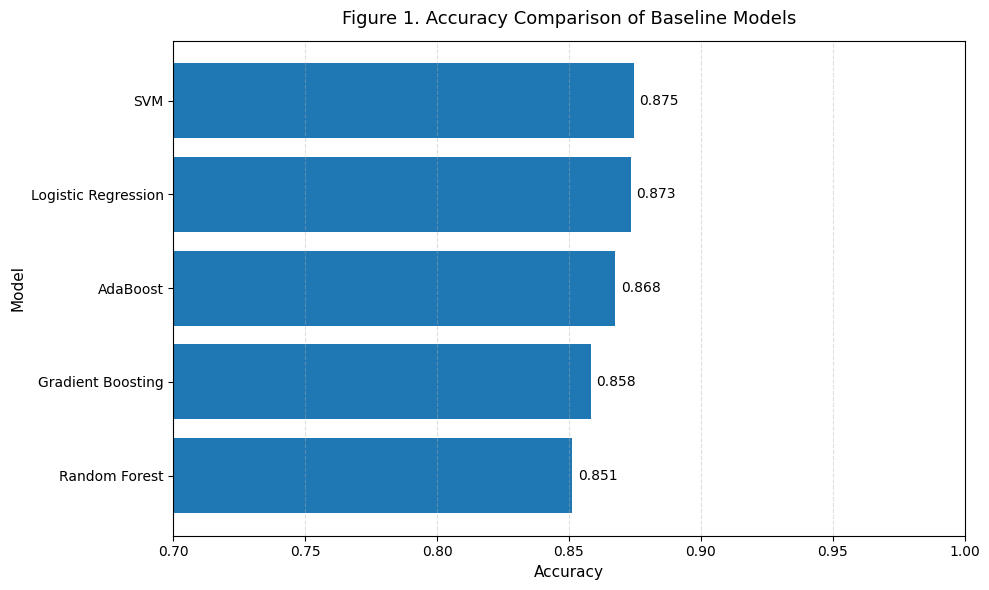

In [27]:

# FIGURE 1 - BASELINE ACCURACY ONLY

plot_df = results_df.sort_values(by="Accuracy", ascending=True)

plt.figure(figsize=(10, 6))
bars = plt.barh(plot_df["Model"], plot_df["Accuracy"])

plt.xlabel("Accuracy", fontsize=11)
plt.ylabel("Model", fontsize=11)
plt.title("Figure 1. Accuracy Comparison of Baseline Models", fontsize=13, pad=12)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.002,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center",
        fontsize=10
    )

plt.xlim(0.70, 1.00)
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

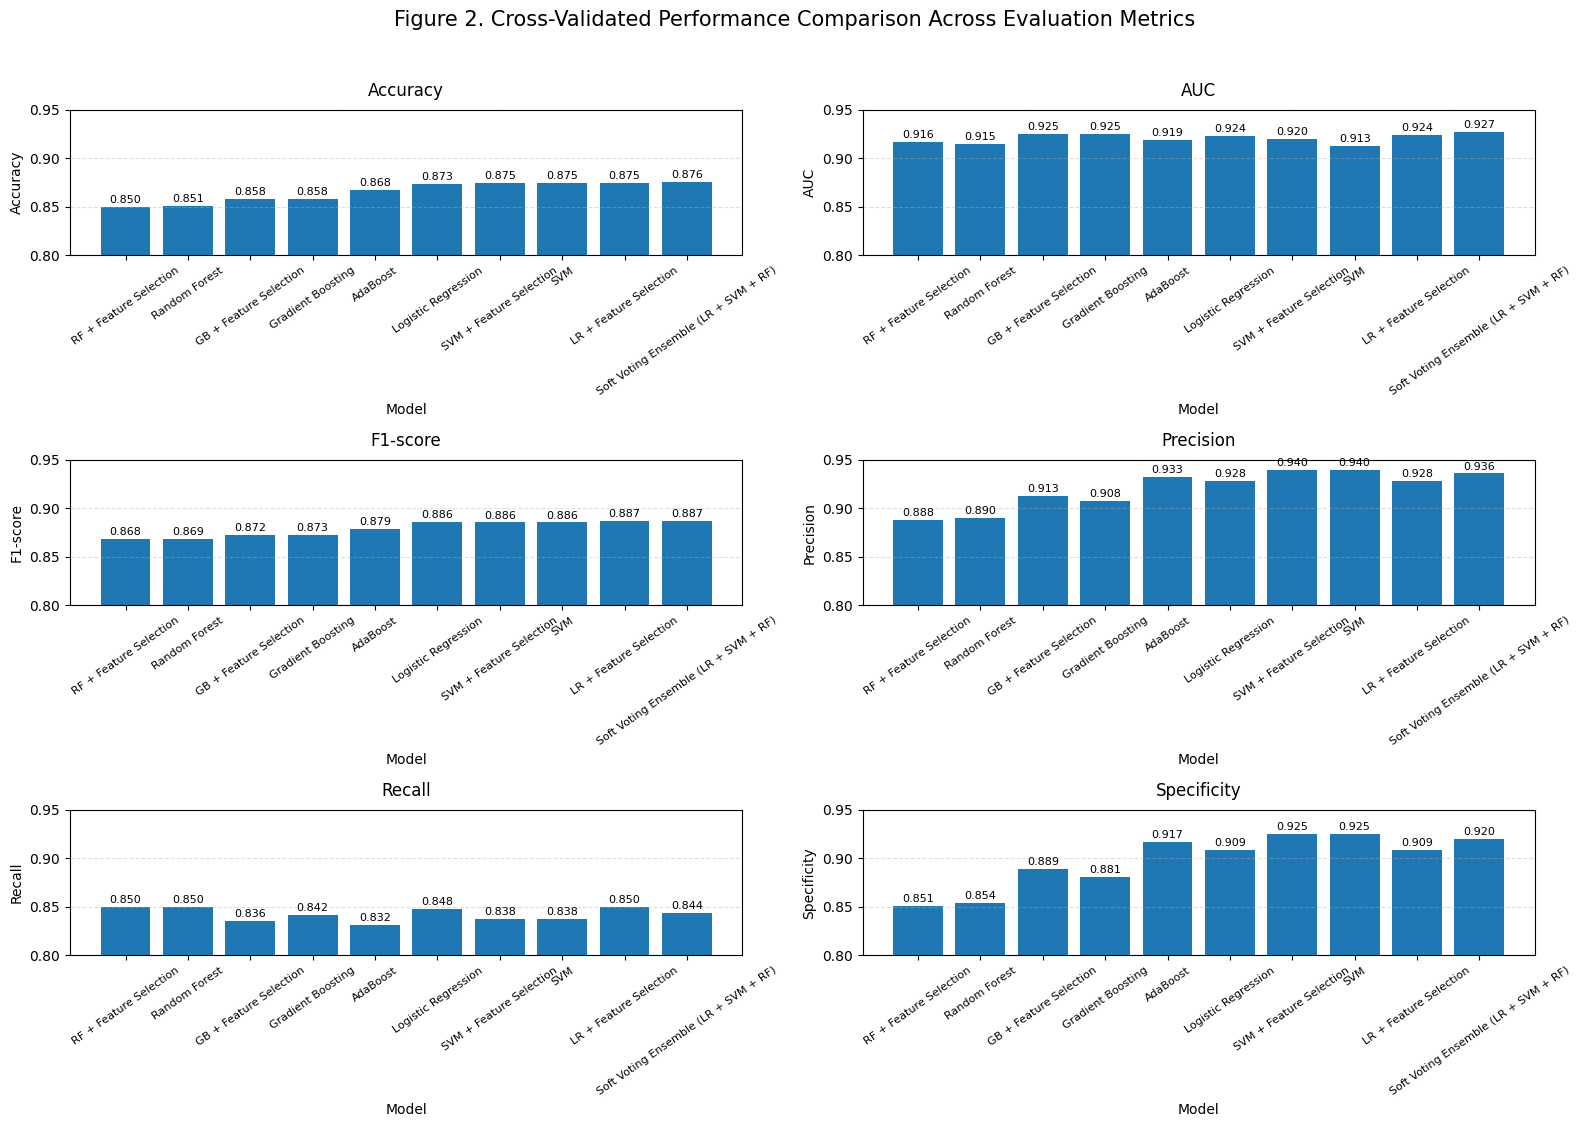

In [28]:
# 2. FIGURE 2 - MULTI-PANEL BAR PLOTS (BEST VERSION)
fig, axes = plt.subplots(3, 2, figsize=(16, 11))

metrics = [
    ("Accuracy", "Accuracy"),
    ("AUC", "AUC"),
    ("F1-score", "F1-score"),
    ("Precision", "Precision"),
    ("Recall", "Recall"),
    ("Specificity", "Specificity")
]

axes = axes.flatten()

# Fixed model order based on accuracy
plot_df = final_results.sort_values(by="Accuracy", ascending=True).reset_index(drop=True)

for i, (metric, title) in enumerate(metrics):
    ax = axes[i]

    bars = ax.bar(plot_df["Model"], plot_df[metric])

    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.002,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=8
        )

    ax.set_title(title, fontsize=12, pad=10)
    ax.set_ylabel(metric, fontsize=10)
    ax.set_xlabel("Model", fontsize=10)
    ax.set_ylim(0.80, 0.95)
    ax.tick_params(axis="x", rotation=35, labelsize=8)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

fig.suptitle(
    "Figure 2. Cross-Validated Performance Comparison Across Evaluation Metrics",
    fontsize=15,
    y=1.02
)

plt.tight_layout()
plt.show()

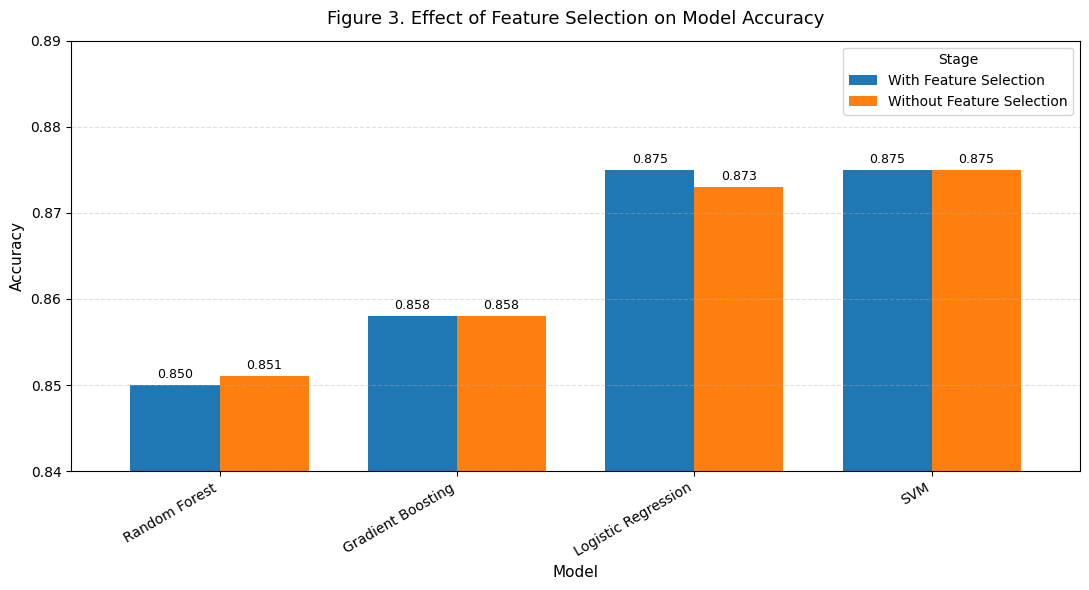

In [29]:
# Figure 3. Effect of feature selection on model accuracy

fs_plot_df = fs_results_df.copy()

name_map = {
    "LR + Feature Selection": "Logistic Regression",
    "SVM + Feature Selection": "SVM",
    "RF + Feature Selection": "Random Forest",
    "GB + Feature Selection": "Gradient Boosting"
}

fs_plot_df["Model"] = fs_plot_df["Model"].replace(name_map)

# Keep only models that appear in both tables
common_models = sorted(set(results_df["Model"]).intersection(set(fs_plot_df["Model"])))

baseline_compare = results_df[results_df["Model"].isin(common_models)][["Model", "Accuracy"]].copy()
baseline_compare["Stage"] = "Without Feature Selection"

fs_compare = fs_plot_df[fs_plot_df["Model"].isin(common_models)][["Model", "Accuracy"]].copy()
fs_compare["Stage"] = "With Feature Selection"

comparison_df = pd.concat([baseline_compare, fs_compare], ignore_index=True)

# Use baseline accuracy order for plotting
model_order = baseline_compare.sort_values(by="Accuracy", ascending=True)["Model"]

pivot_df = comparison_df.pivot(index="Model", columns="Stage", values="Accuracy")
pivot_df = pivot_df.loc[model_order].round(3)

ax = pivot_df.plot(kind="bar", figsize=(11, 6), width=0.75)

ax.set_title("Figure 3. Effect of Feature Selection on Model Accuracy", fontsize=13, pad=12)
ax.set_xlabel("Model", fontsize=11)
ax.set_ylabel("Accuracy", fontsize=11)
ax.set_ylim(0.84, 0.89)
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.4)

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=9, padding=3)

plt.tight_layout()
plt.show()


C:\Program Files\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


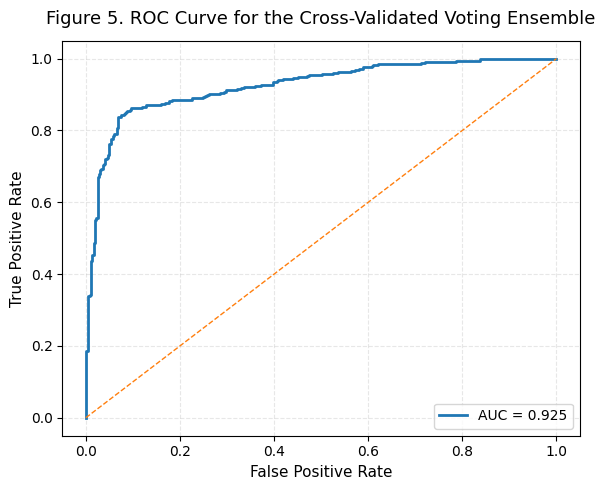

In [30]:
from sklearn.metrics import roc_curve, auc

# Get cross-validated probabilities
y_prob_vote = cross_val_predict(
    voting_pipeline,
    X,
    y_encoded,
    cv=cv,
    method="predict_proba"
)[:, 1]

# Compute ROC
fpr, tpr, _ = roc_curve(y_encoded, y_prob_vote)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)

plt.xlabel("False Positive Rate", fontsize=11)
plt.ylabel("True Positive Rate", fontsize=11)
plt.title("Figure 5. ROC Curve for the Cross-Validated Voting Ensemble", fontsize=13, pad=12)

plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

Total encoded features: 25
Selected features: 19
Coefficient count: 19


,Feature,Coefficient,Importance
3,IDH1_NOT_MUTATED,-3.386,3.386
17,IDH2_NOT_MUTATED,-1.895,1.895
13,NOTCH1_NOT_MUTATED,-1.670,1.670
16,GRIN2A_NOT_MUTATED,1.011,1.011
7,CIC_NOT_MUTATED,-1.000,1.000
4,TP53_NOT_MUTATED,0.831,0.831
11,PIK3R1_NOT_MUTATED,0.825,0.825
10,NF1_NOT_MUTATED,-0.734,0.734
5,PTEN_NOT_MUTATED,0.713,0.713
0,Age_at_diagnosis,-0.713,0.713


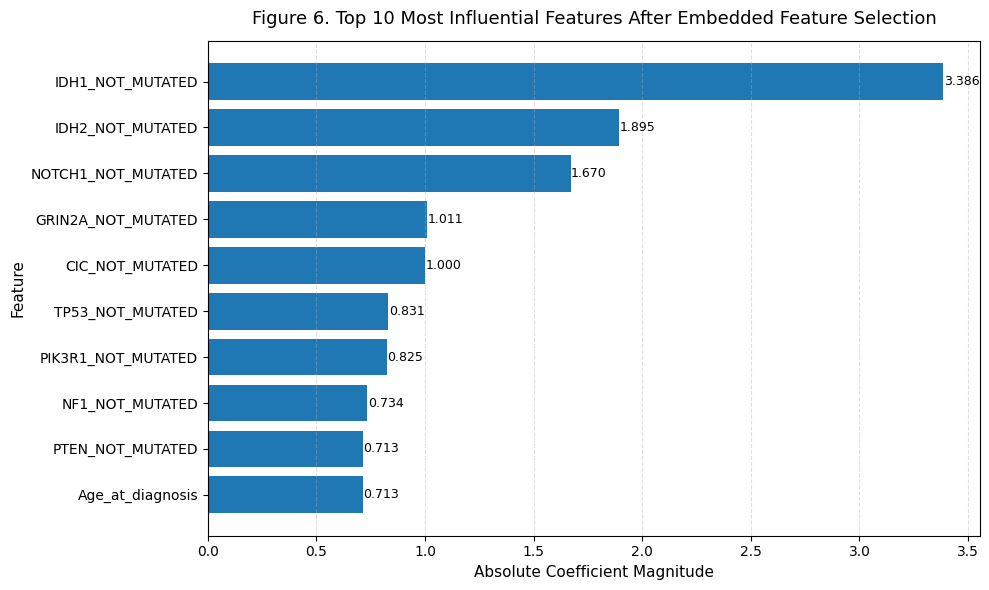

In [31]:
# 6. FIGURE 6 - TOP 10 FEATURE IMPORTANCE AFTER SELECTION
final_pipeline.fit(X, y_encoded)

# Get encoded feature names
ohe = final_pipeline.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
encoded_cat_names = ohe.get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(encoded_cat_names)

# Get selected feature names
selector = final_pipeline.named_steps["selector"]
selected_mask = selector.get_support()
selected_feature_names = np.array(all_feature_names)[selected_mask]

# Get coefficients from final classifier
final_model = final_pipeline.named_steps["classifier"]
selected_coefficients = final_model.coef_[0]

print("Total encoded features:", len(all_feature_names))
print("Selected features:", len(selected_feature_names))
print("Coefficient count:", len(selected_coefficients))

importance_df = pd.DataFrame({
    "Feature": selected_feature_names,
    "Coefficient": selected_coefficients,
    "Importance": np.abs(selected_coefficients)
}).sort_values(by="Importance", ascending=False).round(3)

display(importance_df.head(10))

top10_importance = importance_df.head(10).sort_values(by="Importance", ascending=True)

plt.figure(figsize=(10, 6))
bars = plt.barh(top10_importance["Feature"], top10_importance["Importance"])

plt.xlabel("Absolute Coefficient Magnitude", fontsize=11)
plt.ylabel("Feature", fontsize=11)
plt.title("Figure 6. Top 10 Most Influential Features After Embedded Feature Selection", fontsize=13, pad=12)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.002,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center",
        fontsize=9
    )

plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()